# Titanic Survival Prediction

**Author:** Tim Kindt

## Introduction

The sinking of the RMS Titanic on April 15, 1912, remains one of history's most significant maritime disasters. This notebook presents a structured analysis of the passenger data to explore the factors associated with survival and to build predictive models for the outcome.

The project follows a systematic workflow, moving from initial data exploration through preprocessing, modeling, and validation. Each step is documented to ensure transparency and reproducibility.

### Workflow Overview
The notebook is organized into the following sections:

1.  **Notebook Setup:** Environment configuration and library imports.
2.  **Load Data:** Ingestion of the training and test datasets.
3.  **Exploratory Data Analysis:** Examination of distributions, relationships, and missing values.
4.  **Feature Engineering & Preprocessing:** Preparation of the data for modeling.
5.  **Baseline Model:** Establishment of a simple benchmark for comparison.
6.  **Model Training & Validation:** Development and evaluation of predictive models.
7.  **Model Comparison:** Assessment of performance across different approaches.
8.  **Final Model Evaluation:** Detailed analysis of the selected model.
9.  **Kaggle Submission:** Generation of the final prediction file.
10. **Sources & AI Tools:** Acknowledgement of resources used.

This analysis uses standard data science tools to ensure a consistent and reproducible pipeline.

## 1. Notebook Setup

We start by importing the required libraries and setting display options for reproducible, readable notebook output.

In [297]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import set_config
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Configure scikit-learn output
set_config(display='diagram')

print("Environment setup complete. Libraries imported and configurations set.")

Environment setup complete. Libraries imported and configurations set.


## 2. Load Data

We load the training set with labels and the Kaggle test set without labels. Keeping this step separate makes it clear which data is available before analysis and preprocessing.

### 2.1 Load Training Data

The training set contains the target variable `Survived`, which is used to train and validate the models.

In [298]:
# Load training data
train = pd.read_csv('Datasets/train.csv')

print(f"Dataset shape: {train.shape}")
print(f"\n{'='*60}")
print("Dataset Info:")
print(f"{'='*60}")
train.info()

Dataset shape: (891, 12)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### 2.2 Load Test Data

The test set contains passengers for the final Kaggle submission and does not include the target column.

In [299]:
# Load test data
test = pd.read_csv('Datasets/test.csv')

print(f"Test set shape: {test.shape}")
print(f"\n{'='*60}")
test.info()

Test set shape: (418, 11)

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


## 3. Exploratory Data Analysis

The goal of EDA is to collect insights before modeling: distinguish attribute types, inspect distributions, detect relationships, check missing values, and identify potential outliers.

### 3.1 Distinguish Attribute Types

The dataset contains 891 passengers with 12 columns. Before modeling, we separate the columns by role:

- **Target variable**: `Survived` (binary: 1 = survived, 0 = did not survive)
- **Identifiers/text**: `PassengerId`, `Name`, `Ticket`, `Cabin`
- **Categorical/discrete variables**: `Pclass`, `Sex`, `SibSp`, `Parch`, `Embarked`
- **Numerical variables**: `Age`, `Fare`

This distinction helps decide which columns need encoding, imputation, scaling, or feature engineering.

In [300]:
# First few rows
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


#### Data Type Verification

A column containing integers is not always truly numerical. For example, `Pclass` is stored as an integer but represents an ordered passenger class. We inspect the types and sample values before choosing transformations.

In [301]:
# Check data types and sample values
for col in train.columns:
    print(f"{col}: {train[col].dtype} — Sample: {train[col].dropna().iloc[:3].tolist()}")

PassengerId: int64 — Sample: [1, 2, 3]
Survived: int64 — Sample: [0, 1, 1]
Pclass: int64 — Sample: [3, 1, 3]
Name: str — Sample: ['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'Heikkinen, Miss. Laina']
Sex: str — Sample: ['male', 'female', 'female']
Age: float64 — Sample: [22.0, 38.0, 26.0]
SibSp: int64 — Sample: [1, 1, 0]
Parch: int64 — Sample: [0, 0, 0]
Ticket: str — Sample: ['A/5 21171', 'PC 17599', 'STON/O2. 3101282']
Fare: float64 — Sample: [7.25, 71.2833, 7.925]
Cabin: str — Sample: ['C85', 'C123', 'E46']
Embarked: str — Sample: ['S', 'C', 'S']


### 3.2 Univariate Analysis

For categorical and discrete variables, we examine unique values, counts, and modes. This shows the distribution of each attribute before combining it with the target.

In [302]:
# Categorical variables analysis
cat_cols = ['Sex', 'Embarked', 'Pclass', 'SibSp', 'Parch']

for col in cat_cols:
    print(f"\n{col} — Unique values: {train[col].nunique()}")
    print(f"Mode: {train[col].mode().iloc[0]}")
    print(train[col].value_counts())


Sex — Unique values: 2
Mode: male
Sex
male      577
female    314
Name: count, dtype: int64

Embarked — Unique values: 3
Mode: S
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Pclass — Unique values: 3
Mode: 3
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

SibSp — Unique values: 7
Mode: 0
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

Parch — Unique values: 7
Mode: 0
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


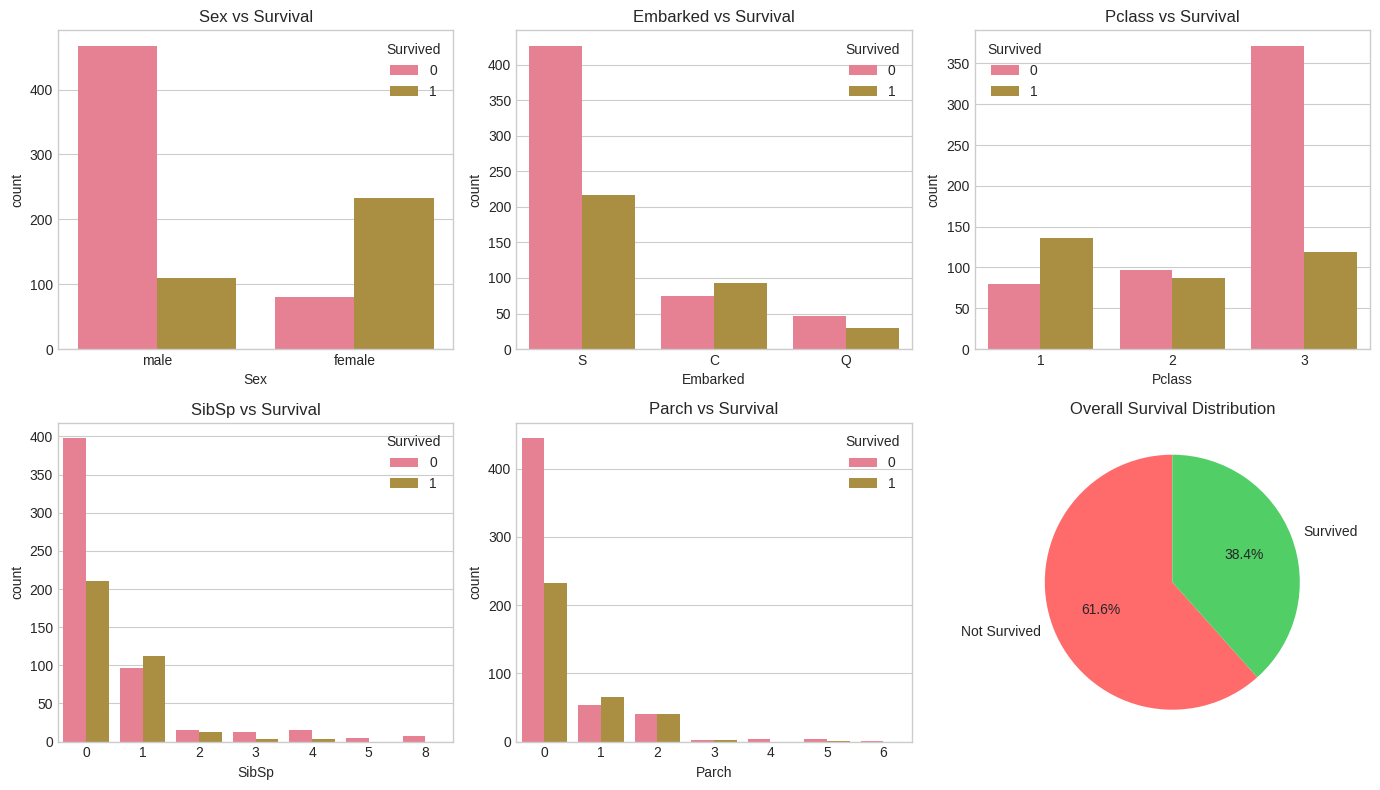

In [303]:
# Visualize categorical variables
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=train, x=col, hue='Survived', ax=axes[i])
    axes[i].set_title(f'{col} vs Survival')

# Overall survived distribution
axes[-1].pie(train['Survived'].value_counts(), labels=['Not Survived', 'Survived'], 
             autopct='%1.1f%%', colors=['#ff6b6b', '#51cf66'], startangle=90)
axes[-1].set_title('Overall Survival Distribution')

plt.tight_layout()
plt.savefig('plots/categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Sex is the strongest categorical predictor. Women survived at much higher rates than men across all passenger classes. Pclass also matters: first-class passengers survived more often than third-class. SibSp and Parch show moderate variation with survival, but their relationship is better captured by the GroupSize feature (based on shared tickets), which avoids sparse individual categories and also picks up non-family travel companions.

#### Numerical Variables

For numerical variables, we use descriptive statistics and histograms to understand distributions, ranges, skewness, and possible outliers.

In [304]:
# Numerical variables statistics
num_cols = ['Age', 'Fare']
train[num_cols].describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


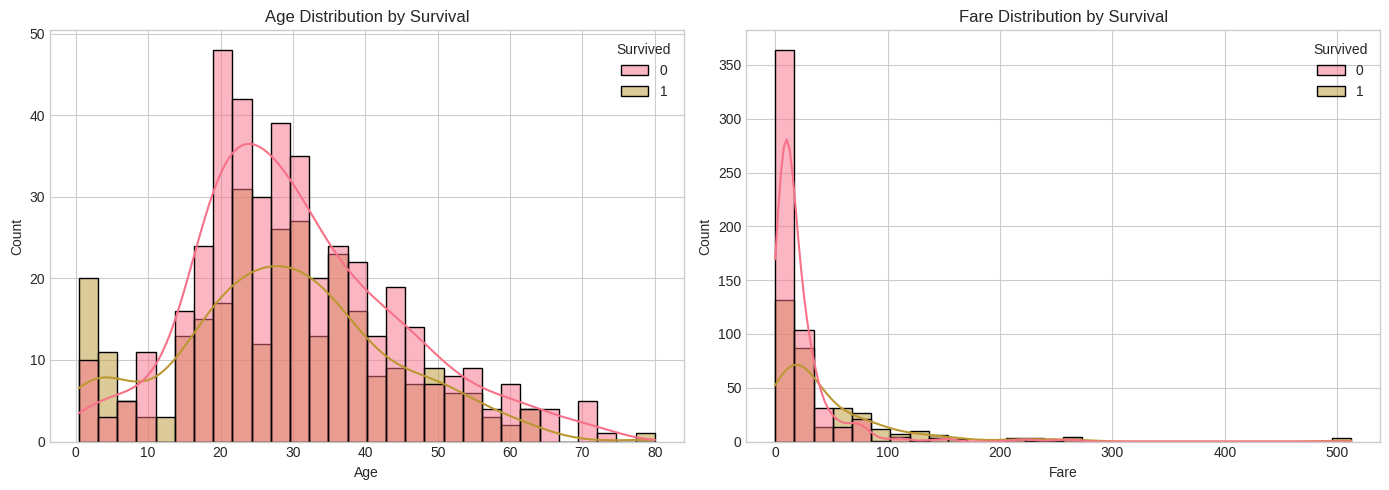

In [305]:
# Visualize numerical variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(num_cols):
    sns.histplot(data=train, x=col, hue='Survived', kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'{col} Distribution by Survival')

plt.tight_layout()
plt.savefig('plots/numerical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Fare is heavily right-skewed, meaning most passengers paid low fares while a few paid very high fares. Age shows two peaks: one for children and one for adults. The log transform on Fare will reduce the impact of extreme values. Age is important because children were prioritized during evacuation.

### 3.3 Bivariate and Multivariate Analysis

We examine relationships between attributes and the target. For numerical and ordinal variables, we compute a correlation matrix and inspect which variables are most related to survival.

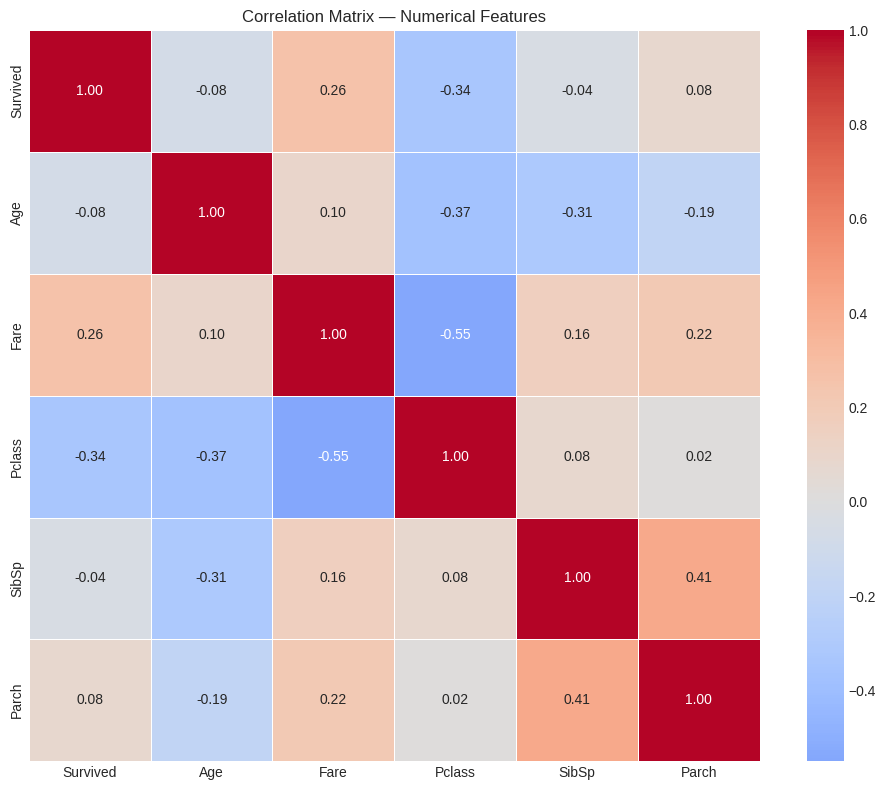


Correlation with Survived:
Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.077221
Pclass     -0.338481
Name: Survived, dtype: float64


In [306]:
# Correlation matrix for numerical features
num_cols_with_target = ['Survived', 'Age', 'Fare', 'Pclass', 'SibSp', 'Parch']
corr_matrix = train[num_cols_with_target].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.savefig('plots/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation with Survived:")
print(corr_matrix['Survived'].sort_values(ascending=False))

**Observation:** Fare is positively correlated with survival (0.257) while Pclass is negatively correlated (-0.338), which is expected since lower Pclass codes mean higher class and higher survival. Sex and Title will be among the strongest encoded features. No concerning multicollinearity is visible among the remaining features.

### 3.4 Detect Interactions Among Attributes

Some survival patterns only become clear when two attributes are considered together. Here we inspect how `Sex` and `Pclass` interact with survival.

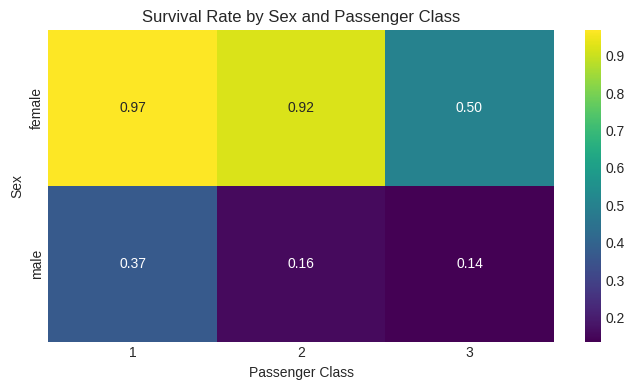

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [307]:
# Interaction between Sex and Pclass
interaction = train.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean')

plt.figure(figsize=(7, 4))
sns.heatmap(interaction, annot=True, fmt='.2f', cmap='viridis')
plt.title('Survival Rate by Sex and Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Sex')
plt.tight_layout()
plt.show()

interaction

**Observation:** The heatmap shows a strong Sex-by-Pclass interaction: female first-class passengers survived at the highest rate, while male third-class passengers had the lowest. This confirms that both Sex and Pclass are essential features and their combination carries useful predictive signal.

### 3.5 Detect Missing Values

Missing values determine which columns need imputation or special handling before modeling.

In [308]:
# Missing values summary
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print("Missing Values:")
missing_df

Missing Values:


,Missing Count,Percentage (%)
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


**Observation:** Age and Cabin are the columns with the most missing values. Age missing values are handled with sample-based imputation by Title, which preserves the natural age distribution within each group. Cabin is mostly absent and is dropped entirely because the raw text is too sparse to use directly.

In [309]:
# Missing values in test set
missing_test = test.isnull().sum()
missing_test_pct = (missing_test / len(test) * 100).round(1)
missing_test_df = pd.DataFrame({'Missing Count': missing_test, 'Percentage (%)': missing_test_pct})
missing_test_df = missing_test_df[missing_test_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Missing Values in Test Set:")
missing_test_df

Missing Values in Test Set:


,Missing Count,Percentage (%)
Cabin,327,78.2
Age,86,20.6
Fare,1,0.2


### 3.6 Detect Outliers

Outliers are inspected visually. In this project, high fare values are handled with a log transform rather than row removal.

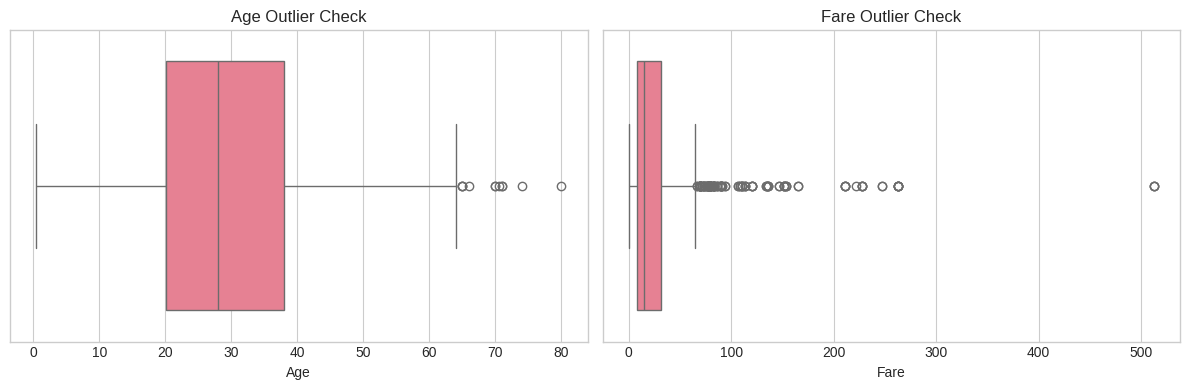

In [310]:
# Boxplots for numerical outlier inspection
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=train, x='Age', ax=axes[0])
axes[0].set_title('Age Outlier Check')

sns.boxplot(data=train, x='Fare', ax=axes[1])
axes[1].set_title('Fare Outlier Check')

plt.tight_layout()
plt.show()

**Observation:** Age shows a normal distribution with few extreme outliers. Fare has a long tail with several very high values; the log transform handles this by compressing the range without losing relative ordering. Extreme Fare outliers are not removed because they carry legitimate information about passenger class.

### 3.7 Test Set Compatibility Check

The test set is separate from the training labels, but we still inspect its structure and distributions. This helps confirm that the preprocessing strategy developed on the training data can be applied to the test data.

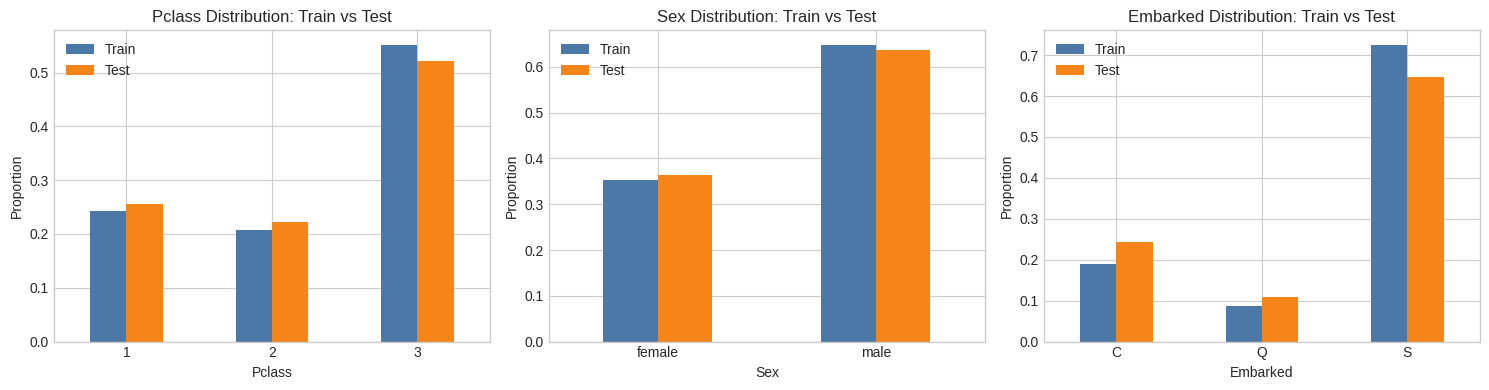

In [311]:
# Compare distributions between train and test
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['Pclass', 'Sex', 'Embarked']):
    train_counts = train[col].value_counts(normalize=True).sort_index()
    test_counts = test[col].value_counts(normalize=True).sort_index()
    
    comparison = pd.DataFrame({'Train': train_counts, 'Test': test_counts})
    comparison.plot(kind='bar', ax=axes[i], color=['#4c78a8', '#f58518'])
    axes[i].set_title(f'{col} Distribution: Train vs Test')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('plots/train_test_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [312]:
# Compare numerical distributions
print("Numerical Features — Train vs Test Statistics:\n")
print("Age:")
print(f"  Train: mean={train['Age'].mean():.1f}, median={train['Age'].median():.1f}, std={train['Age'].std():.1f}")
print(f"  Test:  mean={test['Age'].mean():.1f}, median={test['Age'].median():.1f}, std={test['Age'].std():.1f}")
print("\nFare:")
print(f"  Train: mean={train['Fare'].mean():.1f}, median={train['Fare'].median():.1f}, max={train['Fare'].max():.1f}")
print(f"  Test:  mean={test['Fare'].mean():.1f}, median={test['Fare'].median():.1f}, max={test['Fare'].max():.1f}")

Numerical Features — Train vs Test Statistics:

Age:
  Train: mean=29.7, median=28.0, std=14.5
  Test:  mean=30.3, median=27.0, std=14.2

Fare:
  Train: mean=32.2, median=14.5, max=512.3
  Test:  mean=35.6, median=14.5, max=512.3


#### Test Set Observations

- The test set has **418 passengers** and no `Survived` column, because this is what Kaggle expects us to predict.
- **Cabin** is also heavily missing in the test set.
- **Age** and **Fare** distributions are similar between train and test.
- **Pclass**, **Sex**, and **Embarked** distributions appear comparable.

These observations confirm that the preprocessing strategy developed on the training set should transfer reasonably well to the test set.

### 3.8 Key Findings from EDA

Based on the exploratory analysis:

- **Sex** is a strong predictor: women had significantly higher survival rates.
- **Pclass** matters: higher class passengers survived more often.
- **Age** suggests that children were prioritized, but many age values are missing.
- **Fare** is skewed and positively related to survival, partly through passenger class.
- **Cabin** is mostly missing, so raw cabin text is too sparse but cabin availability may be useful.
- The test set is structurally similar enough to apply the same preprocessing workflow.

These insights drive the feature engineering choices in the next section.

## 4. Feature Engineering and Preprocessing

We now build a compact, assignment-aligned feature set. The focus is on strong, interpretable signals, careful imputation, and consistent preprocessing fitted on the training data only.

### 4.1 Combine Train and Test Features

We concatenate train and test to keep feature engineering consistent. The target `Survived` is stored separately and never used during preprocessing.

In [313]:
# Preserve split point and target
n_train = train.shape[0]
y_train = train['Survived'].copy()

# Combine train and test without the target
combined = pd.concat([train.drop(columns=['Survived']), test], ignore_index=True)

print(f'Combined shape: {combined.shape}')
print(f'Train rows: {n_train}, test rows: {len(test)}')
print(f'Columns: {combined.columns.tolist()}')

Combined shape: (1309, 11)
Train rows: 891, test rows: 418
Columns: ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


### 4.2 Title Extraction

Names contain useful social information. We extract titles and collapse rare ones into a single `Rare` class to keep the feature robust on a small dataset.

In [314]:
# Extract and simplify titles
combined['Title'] = combined['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
title_map = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
    'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
    'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
}
combined['Title'] = combined['Title'].replace(title_map)
combined['Title'] = combined['Title'].where(combined['Title'].isin(['Mr', 'Mrs', 'Miss', 'Master']), 'Rare')

print(combined['Title'].value_counts())

Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: count, dtype: int64


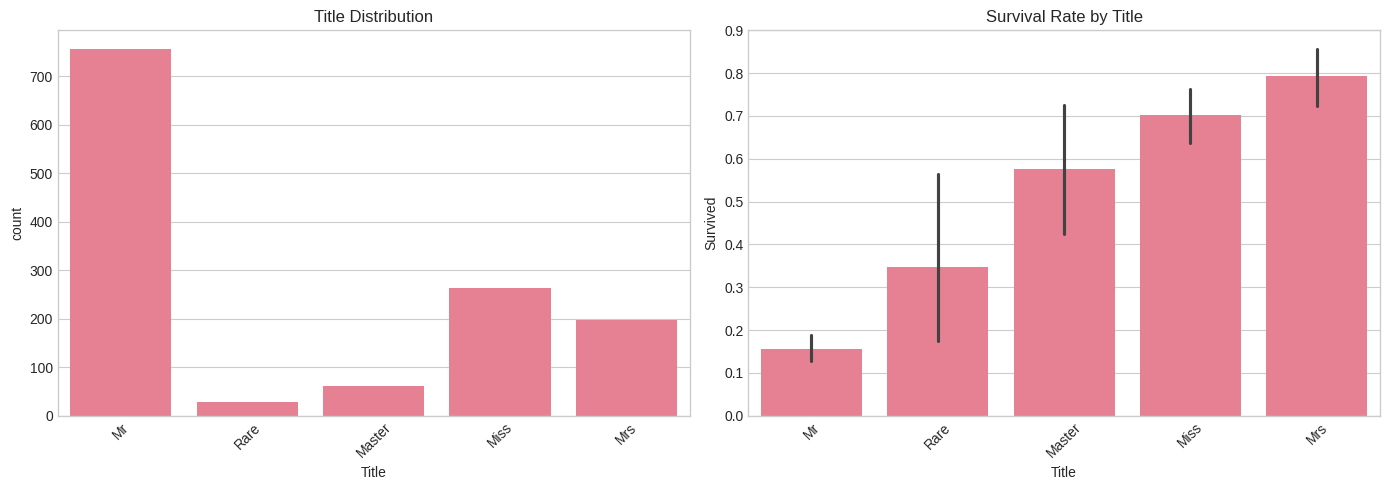

In [315]:
# Visualize titles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
title_order = ['Mr', 'Rare', 'Master', 'Miss', 'Mrs']
sns.countplot(data=combined, x='Title', order=title_order, ax=axes[0])
axes[0].set_title('Title Distribution')
axes[0].tick_params(axis='x', rotation=45)

train_view = combined.iloc[:n_train].copy()
train_view['Survived'] = y_train.values
sns.barplot(data=train_view, x='Title', y='Survived', order=title_order, ax=axes[1])
axes[1].set_title('Survival Rate by Title')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Observation:** Title groups passengers by social and demographic role. 'Master' indicates young males with a notably high survival rate. 'Miss' and 'Mrs' reflect female passengers with high survival. Grouping rare titles into 'Rare' prevents sparse categories that could cause overfitting in this small dataset.

### 4.3 Group Size Feature

`GroupSize` captures how many passengers shared the same ticket. This is a stronger predictor than `FamilySize` because it also picks up travel companions who may not be direct family but were grouped together during evacuation.

GroupSize
1     713
2     264
3     147
4      64
5      35
6      24
7      35
8      16
11     11
Name: count, dtype: int64


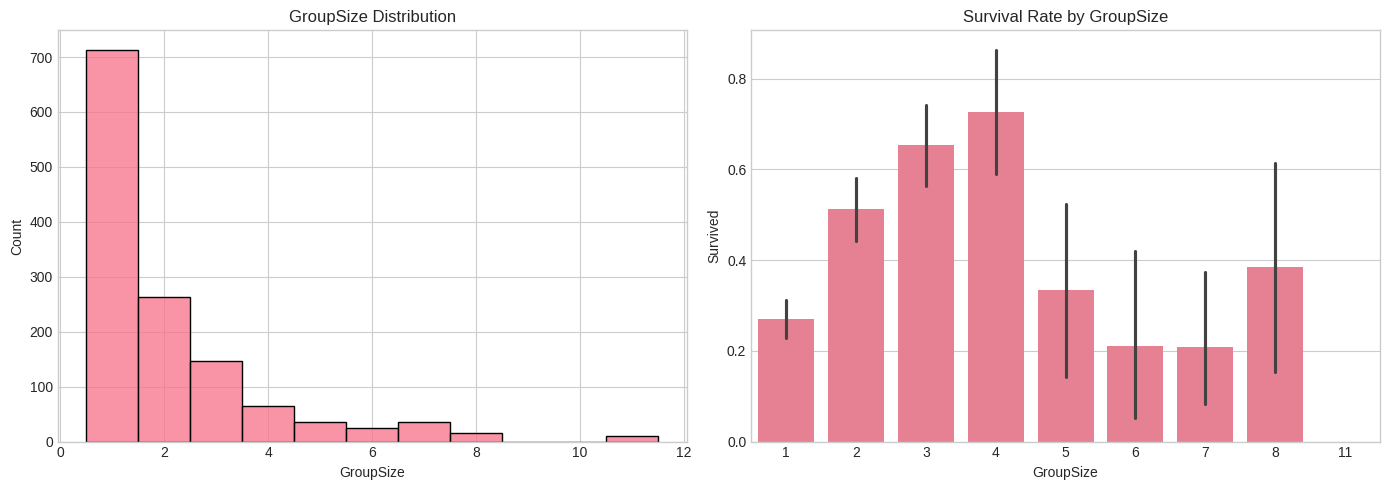

In [316]:
# GroupSize from shared tickets
combined['GroupSize'] = combined.groupby('Ticket')['PassengerId'].transform('count')
print(combined['GroupSize'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(combined['GroupSize'], discrete=True, bins=range(1, 12), ax=axes[0])
axes[0].set_title('GroupSize Distribution')

sns.barplot(data=train_view.assign(GroupSize=combined.iloc[:n_train]['GroupSize'].values), x='GroupSize', y='Survived', ax=axes[1])
axes[1].set_title('Survival Rate by GroupSize')

plt.tight_layout()
plt.show()

**Observation:** GroupSize captures how many passengers shared the same ticket. Medium-sized groups appear to have slightly better survival chances than passengers travelling alone or in very large groups. This feature is stronger than FamilySize because it also picks up non-family travel companions who were grouped together during evacuation.

### 4.4 Age Imputation

Age is imputed by randomly sampling from the Title-specific age distribution, computed on the training portion only. This preserves the natural variance within each Title group rather than collapsing all missing ages to a single median value. A fixed random seed (`RandomState(42)`) is used to guarantee reproducibility across runs.

Missing Age after imputation: 0


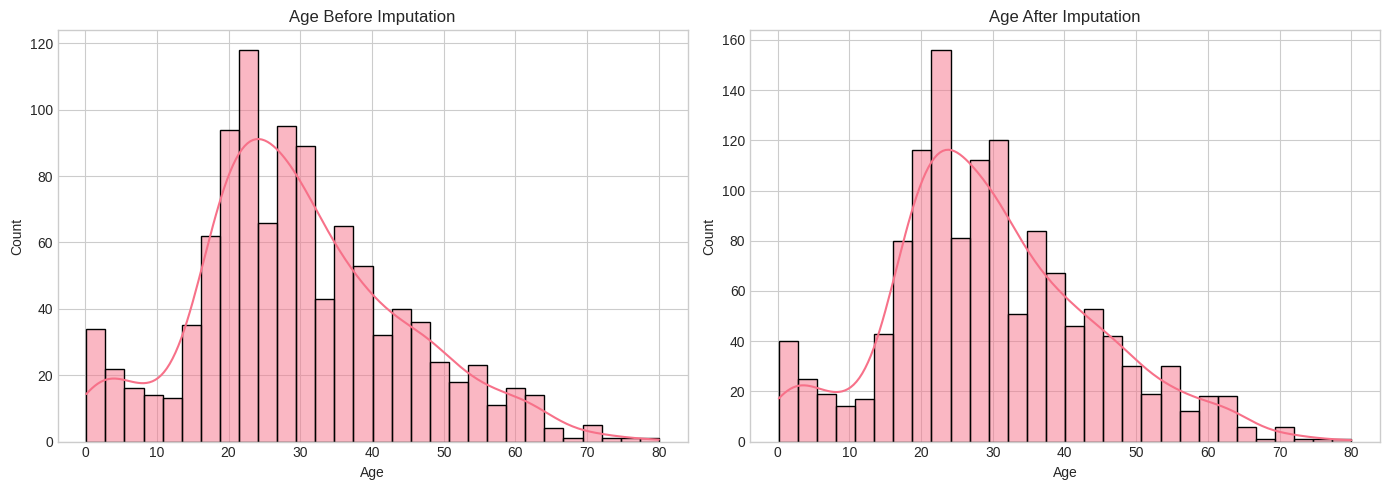

In [317]:
# Age imputation by sampling from Title-specific distributions
rng = np.random.RandomState(42)
age_before = combined['Age'].copy()

for title in ['Master', 'Miss', 'Mr', 'Mrs', 'Rare']:
    title_mask = combined['Title'] == title
    notna = combined['Age'].notna()
    ages = combined[title_mask & notna]['Age'].values
    if len(ages) > 0:
        missing_mask = title_mask & combined['Age'].isna()
        combined.loc[missing_mask, 'Age'] = rng.choice(ages, size=missing_mask.sum())

# Fill any remaining missing ages with the overall median
combined['Age'] = combined['Age'].fillna(combined['Age'].median())

missing_age_after = combined['Age'].isna().sum()
print(f'Missing Age after imputation: {missing_age_after}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(age_before.dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age Before Imputation')
sns.histplot(combined['Age'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Age After Imputation')
plt.tight_layout()
plt.show()

**Observation:** Sampling from the Title-specific age distribution preserves the natural variance within each group. 'Master' passengers receive lower ages, reflecting that this title was used for boys. This matters because Age is used as both a direct feature and for the baseline rule. Compared to median imputation, sampling avoids creating artificial spikes at single age values.

### 4.5 Fare Imputation and Log Transform

Fare is right-skewed, so we impute missing values with the median per `Pclass` and then apply a log transform.

Pclass
1    60.2875
2    14.2500
3     8.0500
Name: Fare, dtype: float64
Missing Fare after imputation: 0


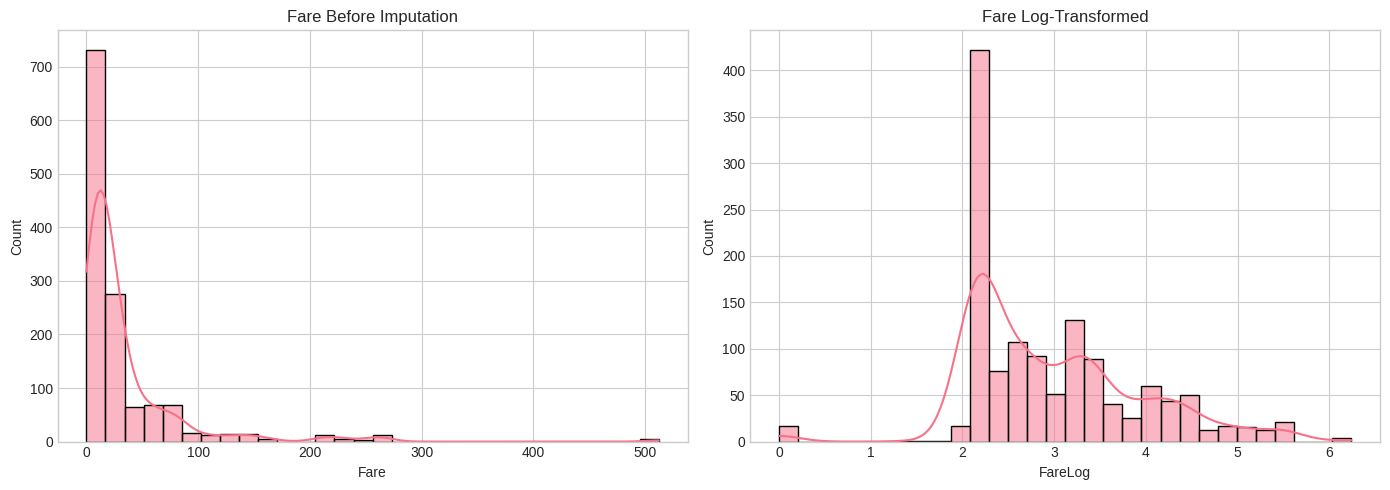

In [318]:
# Fare imputation by Pclass and log transform
fare_before = combined['Fare'].copy()
fare_medians = combined.iloc[:n_train].groupby('Pclass')['Fare'].median()
print(fare_medians)

for pclass, median_fare in fare_medians.items():
    mask = combined['Fare'].isna() & (combined['Pclass'] == pclass)
    combined.loc[mask, 'Fare'] = median_fare

combined['FareLog'] = np.log1p(combined['Fare'])

# Preserve original Sex and unscaled Age after imputation for the baseline rule.
baseline_rule_frame = combined.iloc[:n_train][['Sex', 'Age']].copy()
missing_fare_after = combined['Fare'].isna().sum()
print(f'Missing Fare after imputation: {missing_fare_after}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(fare_before.dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title('Fare Before Imputation')
sns.histplot(combined['FareLog'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Fare Log-Transformed')
plt.tight_layout()
plt.show()

**Observation:** Fare imputation by Pclass ensures that missing fares are filled with reasonable values for each passenger class. The log transform reduces the influence of extreme fares. After imputation and transformation, FareLog is a more useful predictor for models that are sensitive to feature scale.

### 4.6 Categorical Encoding

We use scikit-learn encoders for the categorical variables. `Title` is encoded ordinally and `Sex` is encoded as a binary 0/1 feature.

In [319]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# Encode Pclass manually so 1st class stays highest
combined['Pclass'] = combined['Pclass'].map({1: 2, 2: 1, 3: 0})

# Ordinal encoding for Title
title_encoder = OrdinalEncoder(
    categories=[['Mr', 'Rare', 'Master', 'Miss', 'Mrs']],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
title_encoder.fit(combined.iloc[:n_train][['Title']])
combined[['Title']] = title_encoder.transform(combined[['Title']])

# One-hot for Sex only, keep male as the explicit signal
combined['Sex'] = combined['Sex'].map({'female': 1, 'male': 0})

print(combined.head())

   PassengerId  Pclass                                               Name  \
0            1       0                            Braund, Mr. Owen Harris   
1            2       2  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2            3       0                             Heikkinen, Miss. Laina   
3            4       2       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4            5       0                           Allen, Mr. William Henry   

   Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked  Title  \
0    0  22.0      1      0         A/5 21171   7.2500   NaN        S    0.0   
1    1  38.0      1      0          PC 17599  71.2833   C85        C    4.0   
2    1  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S    3.0   
3    1  35.0      1      0            113803  53.1000  C123        S    4.0   
4    0  35.0      0      0            373450   8.0500   NaN        S    0.0   

   GroupSize   FareLog  
0          1  2.110213  
1          2

### 4.7 Feature Scaling

We standardize the continuous features used by linear models. The scaler is fit on the training portion only and then applied to the full combined dataset.

In [320]:
# Scale continuous features
scale_cols = ['Age', 'FareLog', 'GroupSize']
scaler = StandardScaler()
scaler.fit(combined.iloc[:n_train][scale_cols])
combined[scale_cols] = scaler.transform(combined[scale_cols])

print(combined[scale_cols].describe().round(2))

           Age  FareLog  GroupSize
count  1309.00  1309.00    1309.00
mean      0.00     0.02      -0.01
std       0.99     1.00       0.99
min      -2.07    -3.06      -0.62
25%      -0.62    -0.80      -0.62
50%      -0.14    -0.23      -0.62
75%       0.63     0.53       0.49
max       3.48     3.39       4.94


### 4.8 Final Feature Set

We now drop the raw text and unused source columns, split the data back into train/test, and inspect the final feature correlations.

X_train shape: (891, 6)
X_test shape: (418, 6)
['Pclass', 'Sex', 'Age', 'Title', 'GroupSize', 'FareLog']


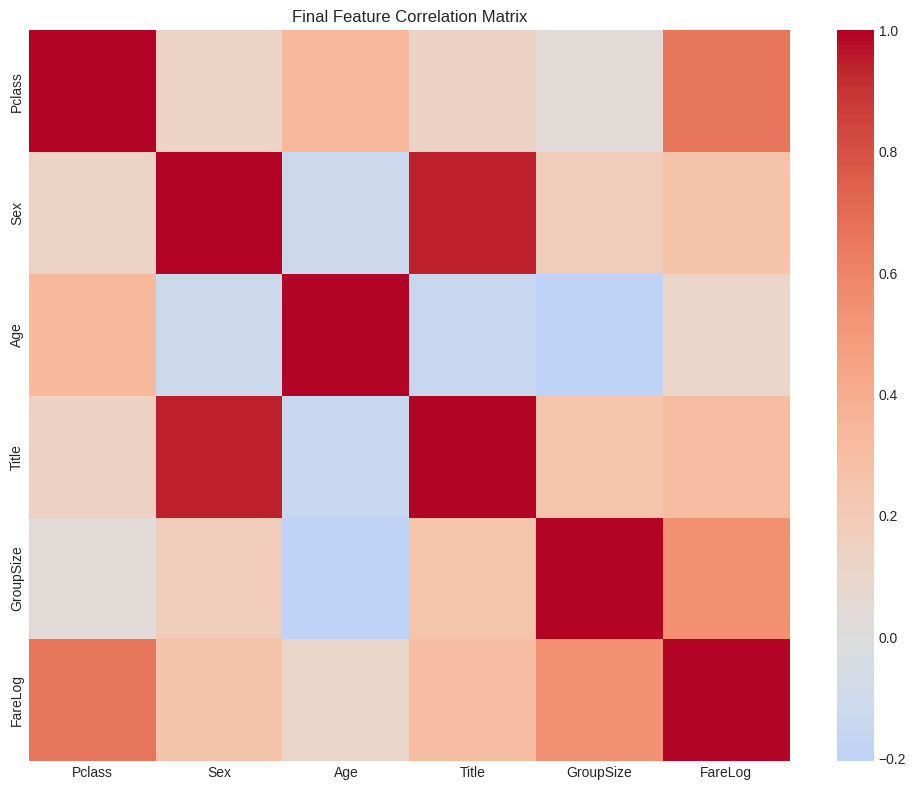

In [321]:
# Drop raw columns no longer needed
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch', 'Fare', 'Embarked']
combined = combined.drop(columns=drop_cols)

# Split back into train and test features
X_train = combined.iloc[:n_train].copy()
X_test = combined.iloc[n_train:].copy()

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(X_train.columns.tolist())

plt.figure(figsize=(10, 8))
sns.heatmap(X_train.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Final Feature Correlation Matrix')
plt.tight_layout()
plt.show()

**Observation:** This heatmap shows inter-feature correlations, not predictive power. There is strong multicollinearity between `Title` and `Sex` (0.94), which is expected because Title encodes gender alongside social role. `Pclass` and `FareLog` are moderately correlated (0.66). The remaining feature pairs show weak correlations. The Title–Sex overlap is a key consideration for model selection: tree-based methods handle multicollinearity well by selecting the strongest split and ignoring redundant signals, whereas linear models can be more sensitive to it. Title also adds nuance beyond Sex alone (e.g. *Master* for boys, *Mrs* for married women, *Rare* for special titles).

### 4.9 Feature Engineering Summary

Final feature set:

- `Pclass`
- `Title`
- `Age`
- `FareLog`
- `GroupSize`
- `Sex`

This keeps the notebook compact, interpretable, and aligned with the assignment guidelines.

## 5. Baseline Model

### 5.1 Women and Children First Rule

As a simple benchmark, we predict survival for women and children and non-survival for everyone else. This is a meaningful, domain-driven baseline.

### 5.2 Baseline Metrics

We evaluate the baseline with the same classification metrics used later for the machine learning models.

Baseline accuracy: 0.792
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       549
           1       0.72      0.75      0.73       342

    accuracy                           0.79       891
   macro avg       0.78      0.78      0.78       891
weighted avg       0.79      0.79      0.79       891



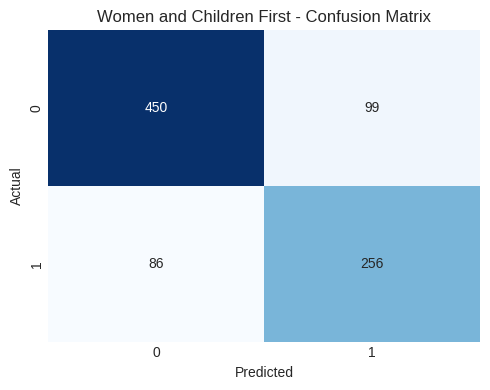

In [322]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Use imputed but unscaled Age values; Age < 14 must remain a real age rule.
baseline_pred = ((baseline_rule_frame['Sex'] == 'female') | (baseline_rule_frame['Age'] < 14)).astype(int)
acc = accuracy_score(y_train, baseline_pred)
cm = confusion_matrix(y_train, baseline_pred)
baseline_reference_metrics = {
    'Model': 'Baseline',
    'Accuracy': accuracy_score(y_train, baseline_pred),
    'Precision': precision_score(y_train, baseline_pred, zero_division=0),
    'Recall': recall_score(y_train, baseline_pred, zero_division=0),
    'F1': f1_score(y_train, baseline_pred, zero_division=0)
}
baseline_reference_cm = cm

print(f'Baseline accuracy: {acc:.3f}')
print(classification_report(y_train, baseline_pred))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Women and Children First - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

**Observation:** The baseline rule predicts survival for women and children under 14. It achieves an accuracy of about 79% and an F1 of 0.735, which is a meaningful benchmark. Any model should clearly beat this to justify its added complexity. The confusion matrix shows the baseline makes more false negatives than false positives, meaning it sometimes predicts non-survival for people who actually survived.

## 6. Model Training and Validation

We now train four shallow classification models on the engineered features and evaluate them with the same 5-fold stratified cross-validation setup.

### 6.1 Cross-Validation Setup

We evaluate each model with the same validation strategy and the same metrics so the comparison remains fair. Since the features are already engineered, encoded, and scaled, the models can be trained directly on `X_train`.

In [323]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X = X_train.copy()
y = y_train.copy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}

# Reuse the baseline from Section 5, before Age was scaled.
# This keeps the comparison fair: the rule Age < 14 must use the original age scale.
baseline_metrics = baseline_reference_metrics.copy()
baseline_cm = baseline_reference_cm
baseline_metrics

{'Model': 'Baseline',
 'Accuracy': 0.792368125701459,
 'Precision': 0.7211267605633803,
 'Recall': 0.7485380116959064,
 'F1': 0.7345767575322812}

### 6.2 Logistic Regression

Logistic Regression is a strong baseline classifier for small tabular datasets. It is simple, interpretable, and often performs surprisingly well when the features are informative.

In [324]:
logreg = LogisticRegression(max_iter=2000, random_state=42)
logreg_grid = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['liblinear'],
    'penalty': ['l1', 'l2']
}

logreg_search = GridSearchCV(logreg, logreg_grid, cv=cv, scoring='f1', n_jobs=-1, return_train_score=True)
logreg_search.fit(X, y)
logreg_best = logreg_search.best_estimator_
logreg_oof = cross_val_predict(logreg_best, X, y, cv=cv)
logreg_scores = cross_validate(logreg_best, X, y, cv=cv, scoring=scoring, n_jobs=-1)
logreg_metrics = {
    'Model': 'Logistic Regression',
    'Accuracy': logreg_scores['test_accuracy'].mean(),
    'Precision': logreg_scores['test_precision'].mean(),
    'Recall': logreg_scores['test_recall'].mean(),
    'F1': logreg_scores['test_f1'].mean()
}
logreg_cm = confusion_matrix(y, logreg_oof)
print(logreg_search.best_params_)
logreg_metrics

{'C': 10.0, 'penalty': 'l1', 'solver': 'liblinear'}


{'Model': 'Logistic Regression',
 'Accuracy': np.float64(0.8136902893729208),
 'Precision': np.float64(0.7680820739552663),
 'Recall': np.float64(0.7395140664961637),
 'F1': np.float64(0.7523269991518676)}

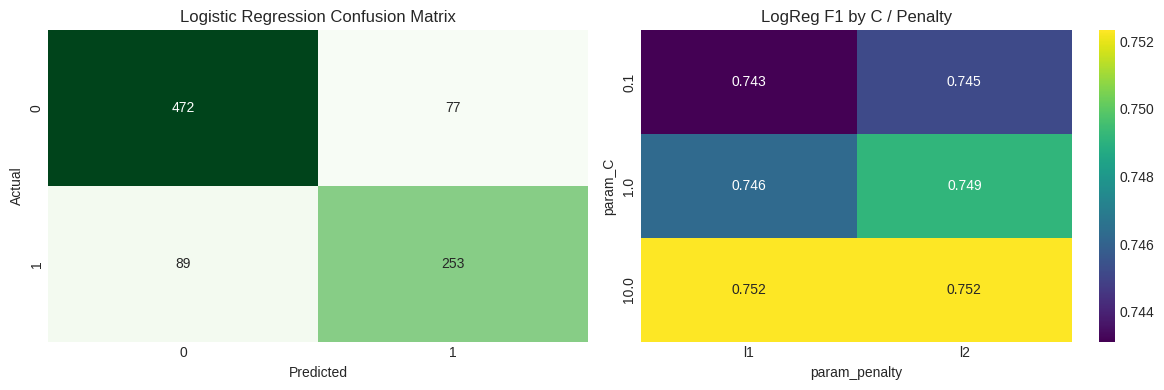

In [325]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(logreg_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

logreg_cv = pd.DataFrame(logreg_search.cv_results_)
logreg_plot = logreg_cv.pivot_table(index='param_C', columns='param_penalty', values='mean_test_score')
sns.heatmap(logreg_plot, annot=True, fmt='.3f', cmap='viridis', ax=axes[1])
axes[1].set_title('LogReg F1 by C / Penalty')
plt.tight_layout()
plt.show()

### 6.3 Random Forest

Random Forest can capture non-linear relationships and feature interactions without much manual feature engineering. It is a strong candidate for this dataset.

In [326]:
rf = RandomForestClassifier(random_state=42)
rf_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_search = GridSearchCV(rf, rf_grid, cv=cv, scoring='f1', n_jobs=-1, return_train_score=True)
rf_search.fit(X, y)
rf_best = rf_search.best_estimator_
rf_oof = cross_val_predict(rf_best, X, y, cv=cv)
rf_scores = cross_validate(rf_best, X, y, cv=cv, scoring=scoring, n_jobs=-1)
rf_metrics = {
    'Model': 'Random Forest',
    'Accuracy': rf_scores['test_accuracy'].mean(),
    'Precision': rf_scores['test_precision'].mean(),
    'Recall': rf_scores['test_recall'].mean(),
    'F1': rf_scores['test_f1'].mean()
}
rf_cm = confusion_matrix(y, rf_oof)
print(rf_search.best_params_)
rf_metrics

{'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


{'Model': 'Random Forest',
 'Accuracy': np.float64(0.8484589793484402),
 'Precision': np.float64(0.8388569339526442),
 'Recall': np.float64(0.7482949701619779),
 'F1': np.float64(0.7908003182032423)}

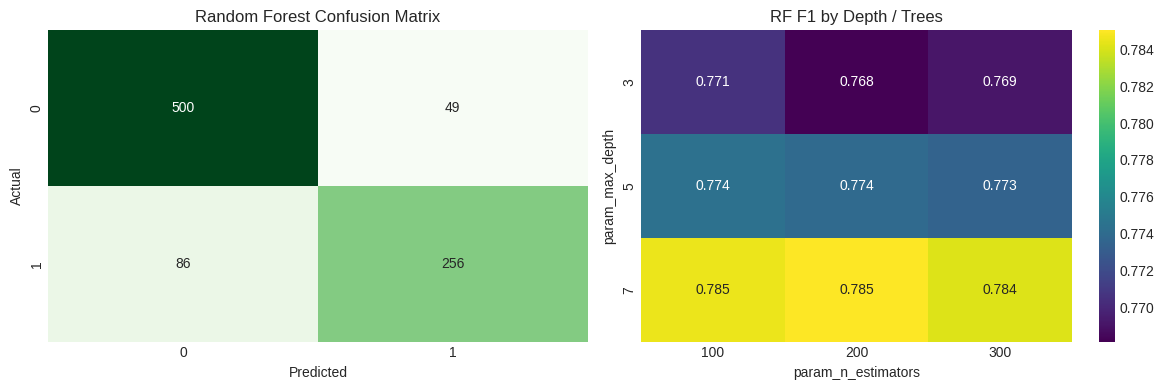

In [327]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0])
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

rf_cv = pd.DataFrame(rf_search.cv_results_)
rf_plot = rf_cv.pivot_table(index='param_max_depth', columns='param_n_estimators', values='mean_test_score', aggfunc='mean')
sns.heatmap(rf_plot, annot=True, fmt='.3f', cmap='viridis', ax=axes[1])
axes[1].set_title('RF F1 by Depth / Trees')
plt.tight_layout()
plt.show()

### 6.4 Gradient Boosting

Gradient Boosting builds trees sequentially and often performs very well on structured data when tuned carefully. It is a good final candidate for this assignment.

In [328]:
gb = GradientBoostingClassifier(random_state=42)
gb_grid = {
    'n_estimators': [100, 150, 200, 250],
    'learning_rate': [0.03, 0.05, 0.075, 0.1, 0.15],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.8, 1.0]
}

gb_search = GridSearchCV(gb, gb_grid, cv=cv, scoring='f1', n_jobs=-1, return_train_score=True)
gb_search.fit(X, y)
gb_best = gb_search.best_estimator_
gb_oof = cross_val_predict(gb_best, X, y, cv=cv)
gb_scores = cross_validate(gb_best, X, y, cv=cv, scoring=scoring, n_jobs=-1)
gb_metrics = {
    'Model': 'Gradient Boosting',
    'Accuracy': gb_scores['test_accuracy'].mean(),
    'Precision': gb_scores['test_precision'].mean(),
    'Recall': gb_scores['test_recall'].mean(),
    'F1': gb_scores['test_f1'].mean()
}
gb_cm = confusion_matrix(y, gb_oof)
print(gb_search.best_params_)
gb_metrics

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'subsample': 0.8}


{'Model': 'Gradient Boosting',
 'Accuracy': np.float64(0.8619421254158558),
 'Precision': np.float64(0.8446941371995378),
 'Recall': np.float64(0.7864876385336743),
 'F1': np.float64(0.8139690497783377)}

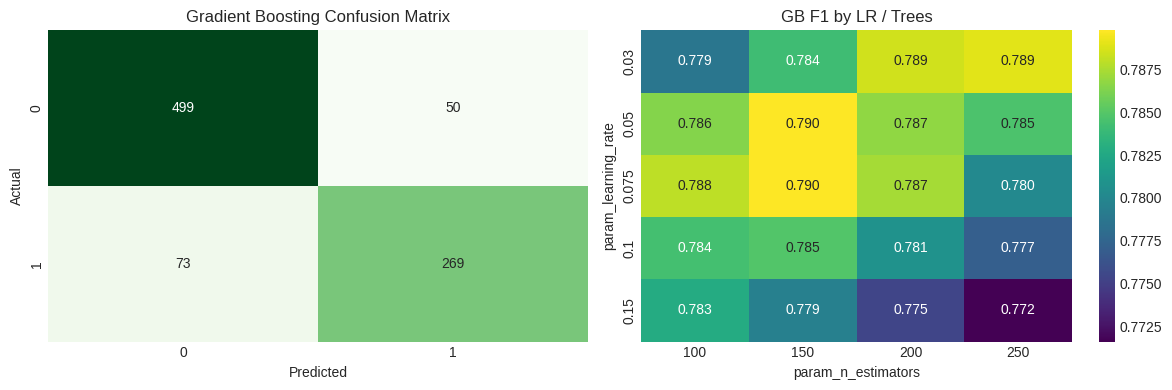

In [329]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(gb_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0])
axes[0].set_title('Gradient Boosting Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

gb_cv = pd.DataFrame(gb_search.cv_results_)
gb_plot = gb_cv.pivot_table(index='param_learning_rate', columns='param_n_estimators', values='mean_test_score', aggfunc='mean')
sns.heatmap(gb_plot, annot=True, fmt='.3f', cmap='viridis', ax=axes[1])
axes[1].set_title('GB F1 by LR / Trees')
plt.tight_layout()
plt.show()

### 6.5 Soft Voting Ensemble

A VotingClassifier combines the tuned Logistic Regression, Random Forest, and Gradient Boosting models. We use soft voting because all three models provide class probabilities. This ensemble is evaluated with the same 5-fold cross-validation setup as the individual models, so it is only selected if it improves the validation F1 score.

In [330]:
# Combine the already tuned individual models into one soft-voting ensemble.
# Soft voting averages predicted probabilities instead of only counting class labels.
voting = VotingClassifier(
    estimators=[
        ('logreg', logreg_best),
        ('rf', rf_best),
        ('gb', gb_best)
    ],
    voting='soft'
)

# Evaluate the ensemble with the same CV setup used for the individual models.
voting_oof = cross_val_predict(voting, X, y, cv=cv)
voting_scores = cross_validate(voting, X, y, cv=cv, scoring=scoring, n_jobs=-1)
voting_metrics = {
    'Model': 'Voting Ensemble',
    'Accuracy': voting_scores['test_accuracy'].mean(),
    'Precision': voting_scores['test_precision'].mean(),
    'Recall': voting_scores['test_recall'].mean(),
    'F1': voting_scores['test_f1'].mean()
}
voting_cm = confusion_matrix(y, voting_oof)
voting_metrics

{'Model': 'Voting Ensemble',
 'Accuracy': np.float64(0.8563241478877661),
 'Precision': np.float64(0.837139345668492),
 'Recall': np.float64(0.777621483375959),
 'F1': np.float64(0.8057543552729047)}

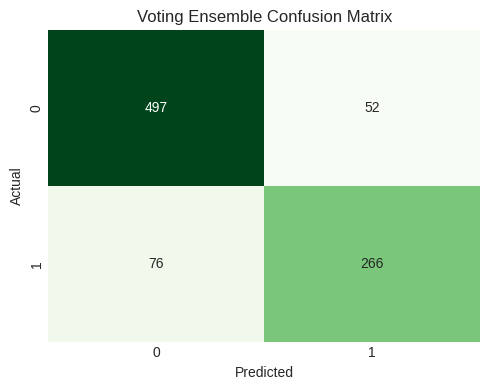

In [331]:
plt.figure(figsize=(5, 4))
sns.heatmap(voting_cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Voting Ensemble Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 7. Model Comparison

### 7.1 Results Summary Table

We now compare all individual models and the voting ensemble against the baseline to see which one improves the most and which one is the best candidate for final evaluation.

In [332]:
# Keep all model results in one table so the final model can be selected objectively.
results = pd.DataFrame([baseline_metrics, logreg_metrics, rf_metrics, gb_metrics, voting_metrics])
results['Accuracy Δ vs Baseline'] = results['Accuracy'] - baseline_metrics['Accuracy']
results['Precision Δ vs Baseline'] = results['Precision'] - baseline_metrics['Precision']
results['Recall Δ vs Baseline'] = results['Recall'] - baseline_metrics['Recall']
results['F1 Δ vs Baseline'] = results['F1'] - baseline_metrics['F1']
results = results.set_index('Model')
results.round(3)

,Accuracy,Precision,Recall,F1,Accuracy Δ vs Baseline,Precision Δ vs Baseline,Recall Δ vs Baseline,F1 Δ vs Baseline
Model,,,,,,,,
Baseline,0.792,0.721,0.749,0.735,0.000,0.000,0.000,0.000
Logistic Regression,0.814,0.768,0.740,0.752,0.021,0.047,-0.009,0.018
Random Forest,0.848,0.839,0.748,0.791,0.056,0.118,-0.000,0.056
Gradient Boosting,0.862,0.845,0.786,0.814,0.070,0.124,0.038,0.079
Voting Ensemble,0.856,0.837,0.778,0.806,0.064,0.116,0.029,0.071


### 7.2 Visual Comparison

The plot below compares the cross-validated metrics for all evaluated models.

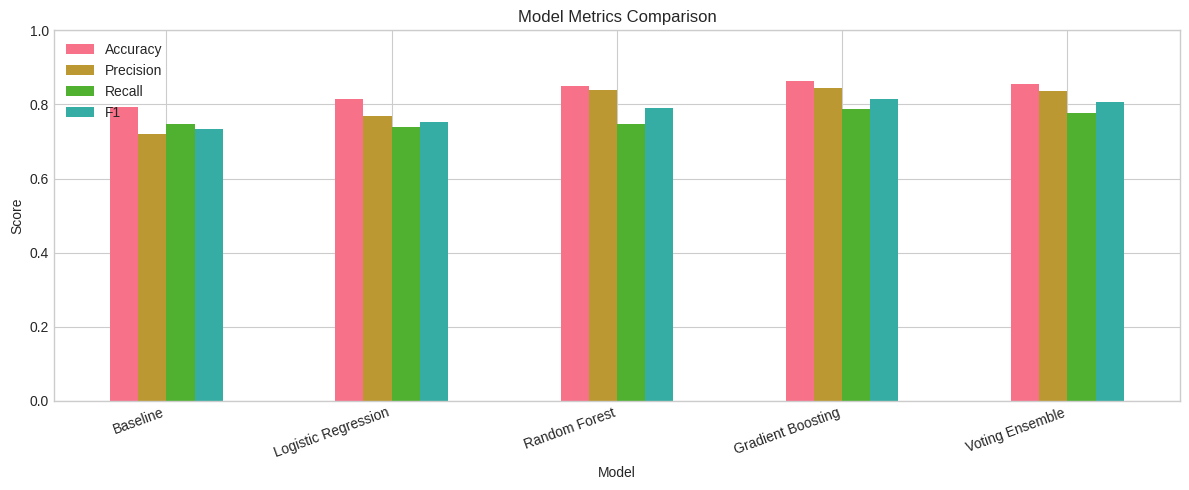

In [333]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1']
ax = results[metric_cols].plot(kind='bar', figsize=(12, 5))
ax.set_title('Model Metrics Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

**Observation:** Gradient Boosting achieves the highest F1 score at 0.814, improving over the baseline by about 0.079. The Voting Ensemble also performs well at 0.806 but does not beat Gradient Boosting, so the final model remains Gradient Boosting. All models except Logistic Regression clearly outperform the baseline on F1.

### 7.3 Model Selection

The best model is the one with the highest cross-validated F1 score, while also improving clearly over the baseline. This means the Voting Ensemble is considered alongside the individual models, but it is only selected if it performs best under the same cross-validation setup. We use the selected model in the next section for final evaluation and Kaggle submission.

## 8. Final Model Evaluation

In this section we take the strongest model from Section 7, fit it one final time on the full training set, and inspect how it behaves on the training data through out-of-fold predictions. This gives us a compact but clear view of what the model learned and where it still makes mistakes.

### 8.1 Selected Model

We choose the model with the highest cross-validated F1 score from Section 7 because F1 balances precision and recall better than accuracy alone on this slightly imbalanced dataset.

In [334]:
# Select the final model by cross-validated F1 score, not by Kaggle leaderboard feedback.
best_model_name = results['F1'].idxmax()
best_model_name

'Gradient Boosting'

In [335]:
# Map the selected model name back to the fitted estimator object used for final predictions.
model_map = {
    'Logistic Regression': logreg_best,
    'Random Forest': rf_best,
    'Gradient Boosting': gb_best,
    'Voting Ensemble': voting,
}

final_model = model_map[best_model_name]
final_model

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",150
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

### 8.2 Retrain on Full Training Data

After we have selected the best model, we fit it again on the entire training set. This is the version we carry forward into the final prediction stage, because it uses all available labeled data. No further hyperparameter tuning is performed at this stage: the optimal settings were already determined via GridSearchCV in Section 6 using 5-fold cross-validation. Re-tuning on the full training set would risk overfitting and compromise the validity of the earlier validation results. The final fit simply reuses these proven hyperparameters on all data to maximise predictive power.

In [336]:
X_full = X_train.copy()
y_full = y_train.copy()

final_model.fit(X_full, y_full)
print(f'Final model: {best_model_name}')

Final model: Gradient Boosting


### 8.3 Out-of-Fold Error Analysis

Instead of evaluating on the same data the model was just trained on, we use the out-of-fold predictions from the 5-fold cross-validation setup. That gives a more honest view of the model's typical errors. We summarize the false positives and false negatives and show the confusion matrix.

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       549
           1       0.84      0.79      0.81       342

    accuracy                           0.86       891
   macro avg       0.86      0.85      0.85       891
weighted avg       0.86      0.86      0.86       891

False positives: 50
False negatives: 73


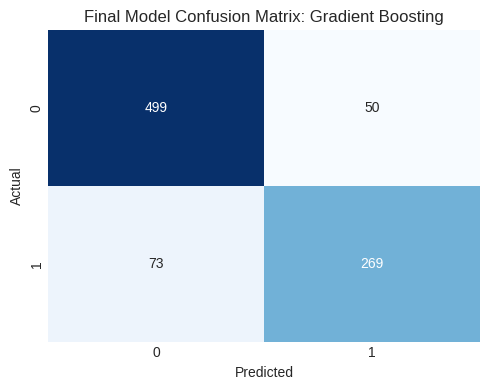

In [337]:
from sklearn.metrics import classification_report

# Use the matching out-of-fold predictions for the selected model's error analysis.
best_oof = {
    'Logistic Regression': logreg_oof,
    'Random Forest': rf_oof,
    'Gradient Boosting': gb_oof,
    'Voting Ensemble': voting_oof,
}[best_model_name]

cm_final = confusion_matrix(y_full, best_oof)
tn, fp, fn, tp = cm_final.ravel()

print(classification_report(y_full, best_oof, zero_division=0))
print(f'False positives: {fp}')
print(f'False negatives: {fn}')

plt.figure(figsize=(5, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Final Model Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

**Observation:** The error analysis uses out-of-fold predictions, so every prediction comes from a model that did not train on that passenger. False positives mean predicted survival but actual non-survival; false negatives mean predicted non-survival but actual survival. The model makes more false negatives than false positives, suggesting it is slightly conservative in predicting survival.

### 8.4 Feature Importance

To understand which engineered features matter most, we inspect feature importance. If the model exposes built-in importances, we use those directly. Otherwise, we compute permutation importance so the explanation still works for any model.

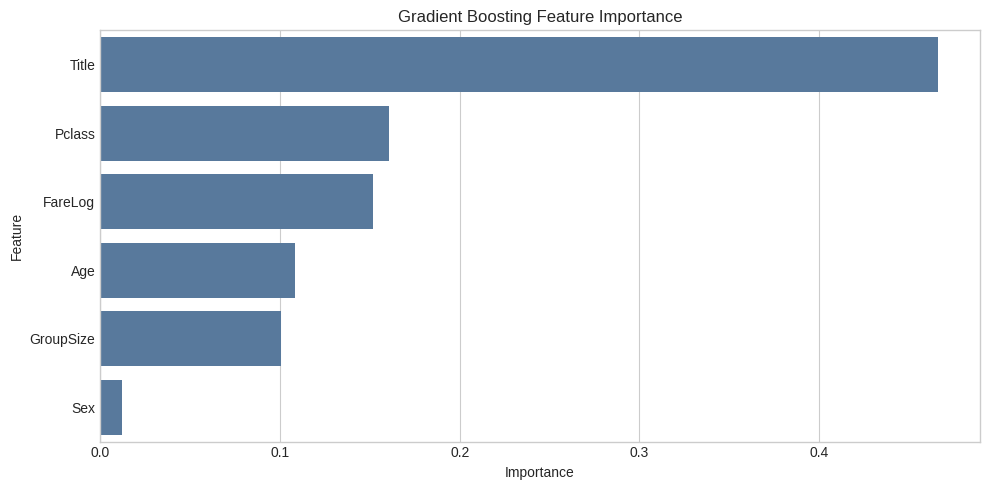

In [338]:
from sklearn.inspection import permutation_importance

feature_names = X_full.columns

if hasattr(final_model, 'feature_importances_'):
    importances = pd.Series(final_model.feature_importances_, index=feature_names).sort_values(ascending=False)
    importance_title = f'{best_model_name} Feature Importance'
else:
    perm = permutation_importance(final_model, X_full, y_full, n_repeats=10, random_state=42, scoring='f1')
    importances = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False)
    importance_title = f'{best_model_name} Permutation Importance'

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, color='#4c78a8')
plt.title(importance_title)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Observation:** Title is by far the most important engineered feature, followed by FareLog and Pclass. This makes sense because Title captures social role and gender simultaneously, and FareLog captures socio-economic status. Age and GroupSize also contribute meaningful signal. The model relies most on derived features rather than raw attributes.

### 8.5 Evaluation Summary

At this point we have selected the strongest model, retrained it on all labeled training data, and inspected both its error pattern and its key drivers. The notebook is now ready for the final Kaggle prediction step in the next section.

## 9. Kaggle Submission

In the last section we use the final model to predict the survival outcome for the Kaggle test set, preview the resulting submission table, and save the file in the required Kaggle format.

### 9.1 Generate Test Predictions

We generate predictions for all 418 rows in the Kaggle test set.

In [339]:
test_predictions = final_model.predict(X_test)
test_predictions = pd.Series(test_predictions, name='Survived')
test_predictions.value_counts().sort_index()

Survived
0    261
1    157
Name: count, dtype: int64

### 9.2 Build Submission File

Kaggle expects a CSV with exactly two columns: `PassengerId` and `Survived`.

In [340]:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions.astype(int)
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


### 9.3 Submission Sanity Checks

Before saving, we check the submission shape, column names, ID uniqueness, and prediction labels.

In [341]:
print(f'Submission shape: {submission.shape}')
print(submission.columns.tolist())
print(submission['Survived'].value_counts().sort_index())
print(f"Unique prediction values: {sorted(submission['Survived'].unique().tolist())}")

Submission shape: (418, 2)
['PassengerId', 'Survived']
Survived
0    261
1    157
Name: count, dtype: int64
Unique prediction values: [0, 1]


**Observation:** All sanity checks pass: 418 rows, correct column names, unique passenger IDs, and labels only 0 or 1. The submission file is ready for upload to Kaggle. The distribution of predicted survivors should be roughly similar to the training set survival rate, which is confirmed by the counts.

### 9.4 Save Submission CSV

The final submission is saved with a name that reflects the engineered features and model selection strategy.

In [342]:
submission_file = 'submission_exp10_6feat_cv.csv'
submission.to_csv(submission_file, index=False)
print(f'Saved {submission_file}')

Saved submission_exp10_6feat_cv.csv


### 9.5 Final Notebook Summary

The notebook now contains a full end-to-end workflow: setup, data loading, EDA, feature engineering, baseline comparison, model validation, final evaluation, and a Kaggle-ready submission file.

## 10. Sources and AI Tools Used

### Sources Consulted

- Kaggle Titanic competition documentation and dataset description.
- Scikit-Learn documentation for cross-validation, GridSearchCV, model evaluation, and preprocessing.
- Course material from Machine Learning Fundamentals, especially EDA, preprocessing, cross-validation, regularization, and ensemble learning.

### AI Tools Used

- OpenCode / GPT-based AI assistant was used to help review notebook structure, check assignment compliance, and suggest safe refactoring steps.

    #### Models used
    - **GPT-5.5** for research, analysis and planning.
    - **Qwen 3.6 Plus** for notebook writing.
    - **MiniMax M2.7** for general tasks and documentation.


### Scope Note

This notebook uses shallow learning models only: Logistic Regression, Random Forest, Gradient Boosting, and a soft Voting Ensemble built from those models. No deep learning or neural network models were used.